# ROS01 - Build a Map by Driving  (LeKiwi - ROS2 - Demo 0)

### Lab Description

Before a robot can navigate it needs a **map**. You teleoperate the LeKiwi around **your** scene once - recording raw stereo video + wheel odometry - then one offline command turns that recording into a 2D occupancy map plus the coloured-block positions that ROS03/ROS04 consume. Because the LeKiwi is **AMD-only**, depth is computed with **RAFT-Stereo on ROCm** (no ZED SDK, no CUDA). Below we define and run the core pieces of that pipeline; the analysis cells read **your own** recording and map, so your result differs from everyone else's. ROS02 does the same mapping autonomously.

#### Recommended Hardware
**LeKiwi** omni-directional base (3x Feetech STS3215 wheels on `/dev/ttyACM0`) + **ZED 2i** stereo camera (USB UVC), driven from an **AMD Ryzen AI** machine (Radeon **gfx1152**, RDNA3.5) - AMD-only, no NVIDIA/CUDA.

#### Software Environment
OS: Ubuntu 24.04 - ROCm 7.13 - PyTorch 2.11 (gfx1152 wheel) - **ROS2 Jazzy** + Nav2 + RTAB-Map - conda env `lerobot-new`. This repo ships **only the LeKiwi ROS2 code** in `lekiwi_ros2/` (repo-relative, so it runs from a clone); it does **not** ship any pre-built map or example run - you produce those yourself on the robot. The `numpy`, `opencv-python`, `pyyaml`, `matplotlib` in `lerobot-new` are enough for the analysis cells. One-time robot setup (the `lerobot-new` env, `bash lekiwi_ros2/utils/setup_raft.sh`, `bash lekiwi_ros2/utils/get_calibration.sh <ZED serial>`) is in `lekiwi_ros2/README.md`.

## Goals
- Record a mapping session by driving the LeKiwi (stereo frames + wheel odometry)
- Define and run the pipeline pieces: disparity->depth, the occupancy-grid encoding, HSV block detection
- Build and inspect YOUR OWN `scene_map.*` + `block_waypoints.txt` (each student's map is different)

> **How this notebook works.** Following the MT06 pattern, each key step is a runnable code cell that **defines the function** doing the work and then runs it. The scene-specific cells read **your own** data - the map *you* build (`utils/scene_map.*`), *your* recorded session (`demo0/rec/...`), *your* `odom.txt` - so **every student's result is different**. Before you have produced that data those cells print a short 'run the robot step first' hint (no canned example is shown). The steps that need the physical robot (camera, motors, ROS2) are `bash` commands you run on the LeKiwi; the full implementations live in `lekiwi_ros2/`.

In [1]:
import os, math, glob, configparser
import numpy as np, cv2, yaml
import matplotlib.pyplot as plt

# This repo ships only the LeKiwi ROS2 code (no pre-built map). You produce the map + data.
ROS2  = os.path.abspath("lekiwi_ros2")
UTILS = f"{ROS2}/utils"
print("repo ROS2 folder:", ROS2)

FREE, OCC, UNKNOWN = 254, 0, 205        # ROS map_server PGM pixel values (white / black / grey)
BLOCK_RGB = {"red": "#e53935", "green": "#43a047", "blue": "#1e88e5", "purple": "#8e24aa"}

def latest_session():
    """Newest recording YOU produced (demo0 manual or demo0-v2 auto). None until you record."""
    recs = sorted(glob.glob(f"{ROS2}/demo0/rec/map*") + glob.glob(f"{ROS2}/demo0-v2/rec/map*"))
    return recs[-1] if recs else None

def have_map(name="scene_map"):
    return os.path.exists(f"{UTILS}/{name}.pgm") and os.path.exists(f"{UTILS}/{name}.yaml")

def load_map(name="scene_map"):
    """Load the occupancy grid YOU built (build_map.sh writes it into utils/). Returns
    (grid, res, ox, oy) with grid[gy, gx], gy increasing upward (the ROS map frame)."""
    m = yaml.safe_load(open(f"{UTILS}/{name}.yaml"))
    res, (ox, oy, _) = m["resolution"], m["origin"]
    with open(f"{UTILS}/{m['image']}", "rb") as f:
        assert f.readline().split()[0] == b"P5"
        t = []
        while len(t) < 3:
            t += f.readline().split(b"#")[0].split()
        W, H = int(t[0]), int(t[1])
        raw = np.frombuffer(f.read(W * H), np.uint8).reshape(H, W)
    return np.ascontiguousarray(np.flipud(raw)), res, ox, oy

def new_map_ax(grid, res, ox, oy, title="", figsize=(6, 5)):
    """Show a grid in metric map-frame coordinates and return the Axes for metric overlays."""
    H, W = grid.shape
    ax = plt.subplots(figsize=figsize)[1]
    ax.imshow(grid, cmap="gray", vmin=0, vmax=255, origin="lower",
              extent=[ox, ox + W * res, oy, oy + H * res])
    ax.set_title(title); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_aspect("equal")
    return ax

def load_waypoints():
    """The colour-block positions YOUR build_map.sh saved: {colour: (x, y)} in the map frame."""
    d = {}
    for ln in open(f"{UTILS}/block_waypoints.txt"):
        c, x, y = ln.split(); d[c] = (float(x), float(y))
    return d

def show_my_map():
    """Show the map YOU built, with your block waypoints. Hints if you have not built one yet."""
    if not have_map():
        print("No map yet. Build YOUR map first (run ROS01 or ROS02 on the robot), then re-run.")
        return
    grid, res, ox, oy = load_map()
    ax = new_map_ax(grid, res, ox, oy, "YOUR scene_map")
    if os.path.exists(f"{UTILS}/block_waypoints.txt"):
        for c, (x, y) in load_waypoints().items():
            ax.scatter(x, y, c=BLOCK_RGB.get(c, "orange"), s=90, ec="k", zorder=5, label=c)
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

repo ROS2 folder: /home/aup/aup-teaching-labs/projects/Physical-AI/Real-Deployment/ROS2-Deployment/lekiwi_ros2


## Step 1 - Drive the robot and record

`demo0/lekiwi_map_gui.py` opens a window with the live camera, WASD driving, and start/stop-recording buttons. Drive a **full loop** of **your** scene and **return to the exact start pose** - that pose becomes the map **origin** ROS03/ROS04 localize at (mark it on the floor). Run it on the robot:

```bash
conda activate lerobot-new
python lekiwi_ros2/demo0/lekiwi_map_gui.py --cam-dev 0
```

It writes `demo0/rec/mapYYYYmmdd_HHMMSS/` with `frames/` (raw left|right stereo), `camera_stamps.txt`, and `odom.txt` (`t x y theta vx vy vtheta`) - your own recording.

## Step 2 - Build the map (one command)

`demo0/build_map.sh` runs four stages automatically (~10-15 min) and writes **your** map into `lekiwi_ros2/utils/`:

```bash
bash lekiwi_ros2/demo0/build_map.sh lekiwi_ros2/demo0/rec/<your-session>
```

The four stages are: **(1)** RAFT-Stereo depth over your recorded pairs, **(2)** RTAB-Map fuses RGB-D + wheel odom into a pose graph and a ray-traced `/map`, **(3)** that grid is saved as `scene_map.pgm/.yaml`, **(4)** your coloured blocks are located and stamped on as obstacles. The next cells define and run the heart of stages 1-4 (on your data once you have it).

### Stage 1 - depth from stereo (no CUDA)

Depth comes from **RAFT-Stereo** on the AMD GPU. Two numbers from **your** ZED's factory calibration (`utils/calib.conf`, produced by `get_calibration.sh`) turn a disparity into metric depth: the left-camera focal length `fx` and the stereo `baseline`. Read yours if you have fetched it (otherwise illustrative values):

In [7]:
def read_calibration(res="VGA"):
    """Read YOUR ZED calibration (utils/calib.conf) -> (fx px, baseline m). Falls back to
    illustrative VGA numbers until you run get_calibration.sh for your camera."""
    path = f"{UTILS}/calib.conf"
    if os.path.exists(path):
        cp = configparser.ConfigParser(); cp.read(path)
        fx = float(cp[f"LEFT_CAM_{res}"]["fx"]); baseline = float(cp["STEREO"]["Baseline"]) / 1000.0
        print("using YOUR calib.conf"); return fx, baseline
    print("no calib.conf yet (run get_calibration.sh) - using illustrative VGA values")
    return 350.0, 0.12

fx, baseline = read_calibration("VGA")
print(f"fx = {fx:.1f} px    baseline = {baseline*100:.1f} cm")

using YOUR calib.conf
fx = 266.2 px    baseline = 12.0 cm


RAFT-Stereo predicts a **disparity** (pixel shift between the left and right image); depth is then a one-liner - larger disparity = closer:

$$\text{depth} = \dfrac{f_x \cdot \text{baseline}}{\text{disparity}}$$

In [8]:
def disparity_to_depth(disparity_px, fx, baseline):
    """Metric depth (m) from stereo disparity (px): depth = fx * baseline / disparity."""
    disparity_px = np.asarray(disparity_px, float)
    depth = np.full_like(disparity_px, np.inf)
    depth[disparity_px > 0] = fx * baseline / disparity_px[disparity_px > 0]
    return depth

for d in [80, 40, 20, 10]:
    print(f"disparity {d:3d} px  ->  depth {float(disparity_to_depth(d, fx, baseline)):.2f} m")

disparity  80 px  ->  depth 0.40 m
disparity  40 px  ->  depth 0.80 m
disparity  20 px  ->  depth 1.60 m
disparity  10 px  ->  depth 3.19 m


**Your own depth output.** After you run `build_map.sh`, RAFT-Stereo has written a metric depth image per frame under your session's `depth_out/depth/` (16-bit mm). Load one of **your** depth frames and view it:

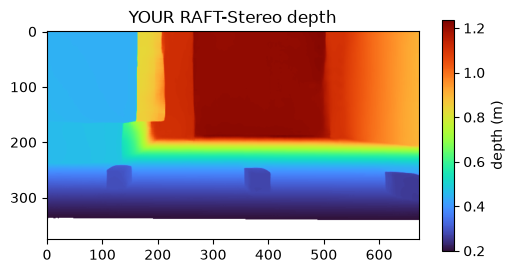

depth range 0.20 - 1.24 m


In [9]:
sess = latest_session()
deps = sorted(glob.glob(f"{sess}/depth_out/depth/*.png")) if sess else []
if deps:
    d_mm = cv2.imread(deps[len(deps)//2], cv2.IMREAD_UNCHANGED).astype(float)
    d_m = np.where(d_mm > 0, d_mm / 1000.0, np.nan)
    plt.figure(figsize=(6, 3)); im = plt.imshow(d_m, cmap="turbo")
    plt.colorbar(im, label="depth (m)"); plt.title("YOUR RAFT-Stereo depth"); plt.show()
    print(f"depth range {np.nanmin(d_m):.2f} - {np.nanmax(d_m):.2f} m")
else:
    print("No depth yet. Record + build_map.sh on the robot, then re-run to see YOURS.")

### Stage 4 - finding the coloured blocks

The blocks are only ~5 cm tall - below the depth obstacle band - so they are found separately. `block_localize.py` masks each colour in HSV, takes the centroid, back-projects it with the median depth (`X=(u-cx)/fx * Z`, `Z=depth`), transforms it to the map frame with the wheel-odom pose, and clusters per colour. The HSV detection is the key step - define it and run it on **your** recorded frame (or a synthetic frame until you have recorded):

detecting on YOUR frame: demo0/rec/map20260721_142129/depth_out/rgb/000034.png
detected pixel centroids: {'red': (643, 279), 'purple': (131, 263), 'green': (377, 259)}


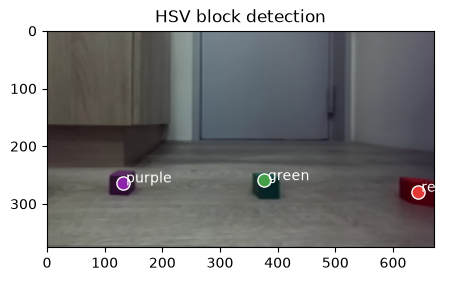

In [10]:
COLORS = {   # OpenCV HSV ranges (H 0-180); red wraps the hue circle
    "red":    [((0,120,50),(8,255,255)), ((170,120,50),(180,255,255))],
    "purple": [((135,80,40),(155,255,255))],
    "blue":   [((116,100,40),(132,255,255))],
    "green":  [((78,90,40),(114,255,255))],
}

def detect_color_blocks(bgr, min_area=120):
    """Find coloured blocks in one camera image by HSV masking + connected components.
    Returns {colour: (u, v) pixel centroid}; block_localize.py then back-projects those."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV); out = {}
    for c, ranges in COLORS.items():
        mask = np.zeros(hsv.shape[:2], np.uint8)
        for lo, hi in ranges:
            mask |= cv2.inRange(hsv, np.array(lo), np.array(hi))
        n, lab, stats, cent = cv2.connectedComponentsWithStats(mask, 8)
        best = max(range(1, n), key=lambda i: stats[i, cv2.CC_STAT_AREA], default=0)
        if best and stats[best, cv2.CC_STAT_AREA] >= min_area:
            out[c] = tuple(int(v) for v in cent[best].round())
    return out

sess = latest_session()
rgbs = sorted(glob.glob(f"{sess}/depth_out/rgb/*.png")) if sess else []
if rgbs:                       # a frame YOU recorded + built
    img = cv2.imread(rgbs[len(rgbs)//2])
    print("detecting on YOUR frame:", os.path.relpath(rgbs[len(rgbs)//2], ROS2))
else:                          # no recording yet: synthetic frame at each range midpoint
    hsv = np.zeros((200, 320, 3), np.uint8); hsv[:] = (0, 0, 120)
    for h, x0, y0 in [(4,30,90), (96,150,90), (124,245,90), (145,40,150)]:
        hsv[y0:y0+45, x0:x0+45] = (h, 200, 210)
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    print("no recording yet - synthetic illustration (record to detect on YOUR frame)")
found = detect_color_blocks(img)
print("detected pixel centroids:", found)
ax = plt.subplots(figsize=(5, 3))[1]; ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
for c, (u, v) in found.items():
    ax.scatter(u, v, s=90, ec="w", c=BLOCK_RGB[c]); ax.annotate(c, (u+6, v), color="w")
ax.set_title("HSV block detection"); plt.show()

### The occupancy grid encoding

RTAB-Map projects the RGB-D + poses into a 2D grid by **ray-tracing**: every cell a camera ray passes *through* becomes free, only the cell it *hits* becomes occupied (which erases the isolated depth-noise specks a point-count grid leaves behind). `grab_grid.py` saves that grid to the map_server PGM values you see as white/grey/black - that thresholding is the whole encoding:

In [11]:
def occupancy_to_pgm(occ):
    """RTAB-Map OccupancyGrid (0..100 = P(occupied), -1 = unknown) -> map_server PGM:
    >=65 occupied(0, black), <0 unknown(205, grey), else free(254, white)."""
    occ = np.asarray(occ, int)
    pgm = np.full(occ.shape, FREE, np.uint8)
    pgm[occ < 0]   = UNKNOWN
    pgm[occ >= 65] = OCC
    return pgm

row = np.array([[-1, 0, 30, 64, 65, 100]])
print("occupancy :", row.tolist()[0])
print("pgm value :", occupancy_to_pgm(row).tolist()[0], "  (254=free  205=unknown  0=occupied)")

occupancy : [-1, 0, 30, 64, 65, 100]
pgm value : [205, 254, 254, 254, 0, 0]   (254=free  205=unknown  0=occupied)


## Your result - the map you built

`build_map.sh` writes `utils/scene_map.pgm/.yaml` + `utils/block_waypoints.txt` for **your** scene. `show_my_map()` reads those, so once you have built your map this shows **yours** (different from every other student's); before that it tells you to build one:

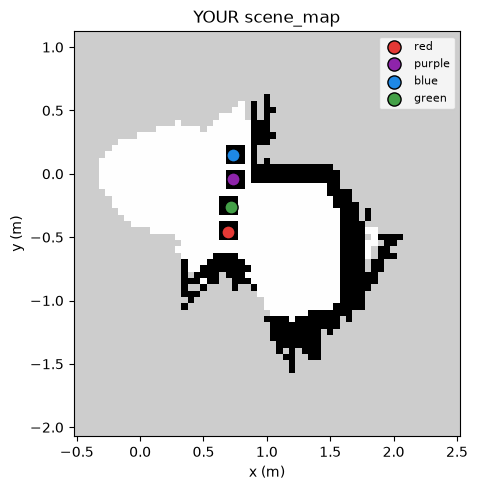

In [12]:
show_my_map()

## Conclusions

You saw the mapping pipeline as runnable pieces - stereo **disparity -> depth** (on AMD ROCm), **HSV block detection**, and the **ray-traced occupancy encoding** - and built **your own** Nav2-ready map with the blocks marked as obstacles. Every later run assumes the robot starts at the same **origin** you recorded from - mark it on the floor. Next: **ROS02** builds a map autonomously; **ROS03** drives to a clicked goal; **ROS04** to a coloured block - all on the map you just made.

## Acknowledgements

Built on the open-source **LeKiwi** base (Hugging Face **LeRobot**), **RAFT-Stereo** (Princeton), **RTAB-Map**, and **Nav2** on **ROS2 Jazzy**, all running on AMD ROCm (gfx1152) with no NVIDIA/CUDA.

---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT